## Exercise 06 : Scatter Matrix

In [1]:
import pandas as pd
import sqlite3
from pandas.plotting import scatter_matrix

### Make a connection to the database

In [2]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

### Run query and create dataframe where each user of test group has average difference, number of pageviews and number of commits

In [3]:
query = """
WITH test AS (
    SELECT checker.uid, labname, timestamp AS first_commit_ts, MIN(datetime) AS first_views_ts
    FROM checker LEFT OUTER JOIN pageviews ON checker.uid = pageviews.uid
    WHERE (checker.status = 'ready'
    AND datetime IS NOT NULL
    AND checker.numTrials = 1
    AND labname IN ('laba04', 'laba04s', 'laba05', 'laba06', 'laba06s')
    AND checker.uid LIKE 'user_%')
    GROUP BY checker.uid, labname
)
SELECT test.uid,
AVG(UNIXEPOCH(first_commit_ts) - deadlines) / 3600 AS avg_diff,
COUNT(DISTINCT pageviews.datetime) AS 'pageviews',
c.num_commits AS num_commits
FROM test
JOIN deadlines ON test.labname = deadlines.labs
LEFT JOIN pageviews ON pageviews.uid = test.uid
JOIN (
    SELECT uid, COUNT(timestamp) AS num_commits
    FROM checker 
    WHERE uid LIKE 'user_%' AND labname != 'project1'
    GROUP BY uid
) AS c ON c.uid = test.uid
GROUP BY test.uid
"""
df = pd.read_sql(sql=query, con=conn)
df 

,uid,avg_diff,pageviews,num_commits
0,user_1,-65.119778,28,62
1,user_10,-75.242444,89,20
2,user_14,-159.568796,143,61
3,user_17,-62.207667,47,51
4,user_18,-6.368148,3,5
5,user_19,-99.440417,16,118
6,user_21,-96.111181,10,65
7,user_25,-93.474944,179,79
8,user_28,-86.793833,149,60
9,user_3,-105.738222,317,18


In [6]:
len(df)

11

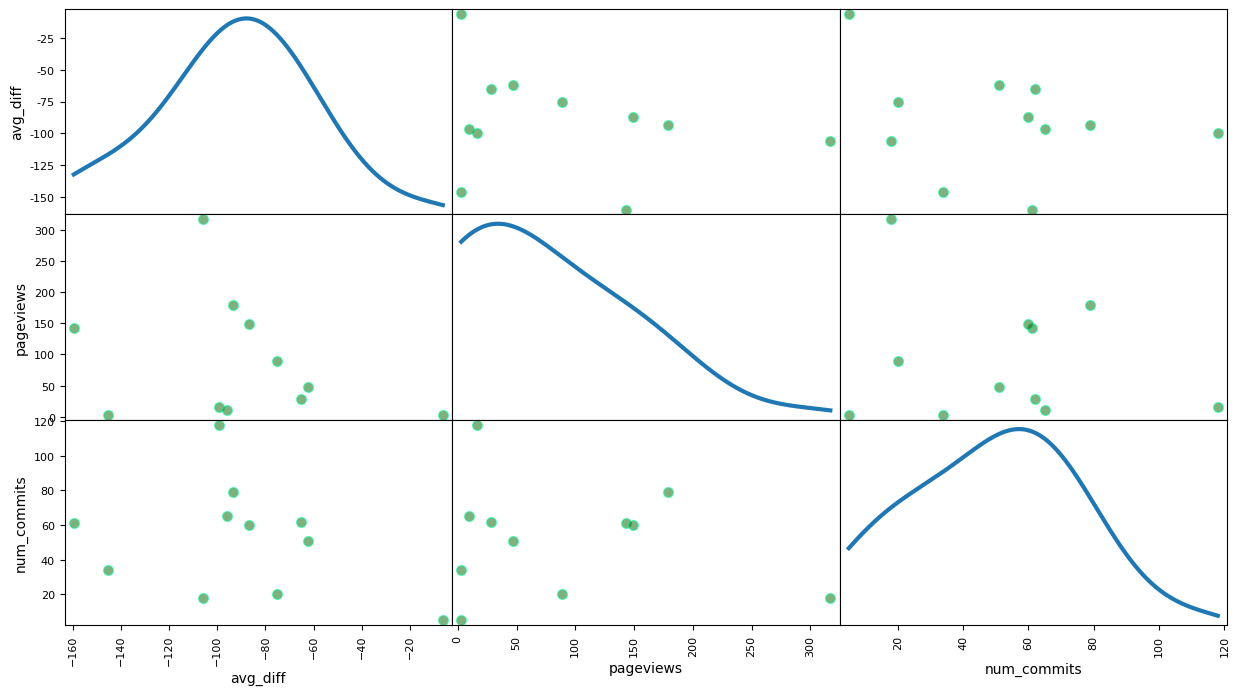

In [4]:
scat_mat = scatter_matrix(df, 
                      figsize=(15, 8), 
                      color='DarkGreen',
                      diagonal='kde',
                      edgecolors='MediumSpringGreen', 
                      s=200, 
                      density_kwds=dict(linewidth=3))

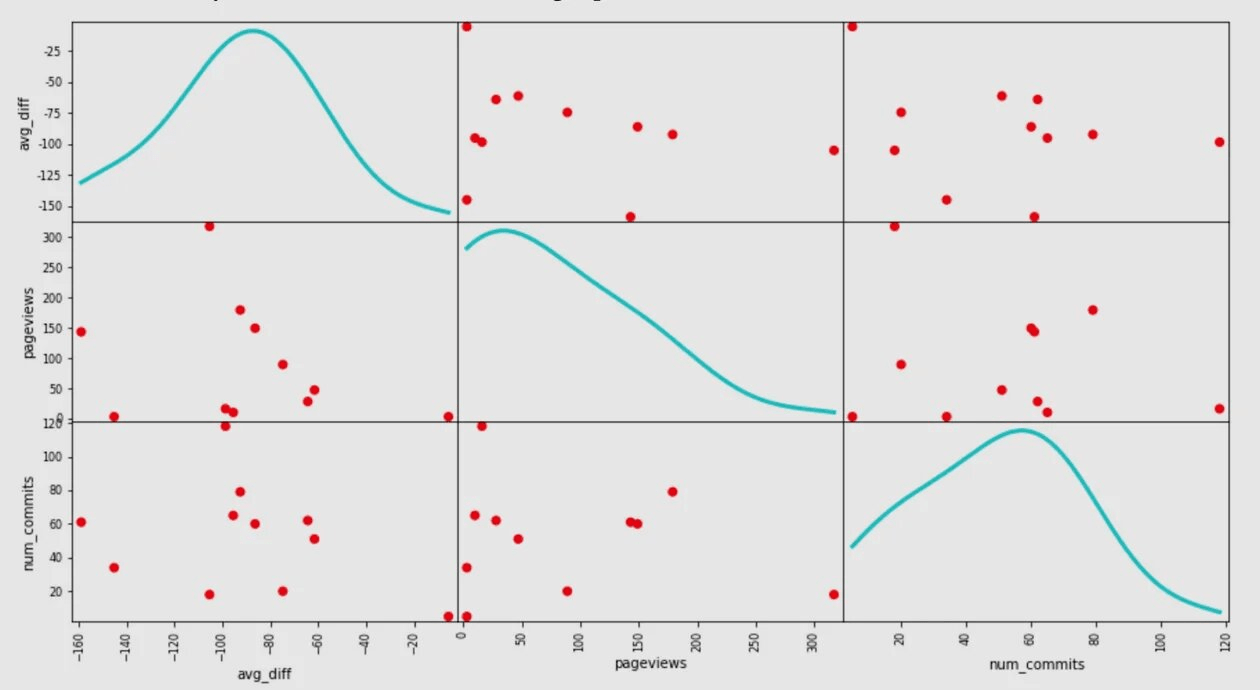

In [5]:
conn.close()

### “Can we say that if a user has a low number of pageviews then they likely have a low number of commits?” 

#### - No

### “Can we say that if a user has a low number of pageviews then they likely have a small average difference between the first commit and the lab deadline?”

#### - No

### “Can we say that there are many users with a low number of commits and a few with a high number of commits?”

#### - Yes

### “Can we say that there are many users with a small average difference and a few with a large average difference?”

#### - No